# 线性代数
:label:`sec_linear-algebra`

在介绍完如何存储和操作数据后，接下来将简要地回顾一下部分基本线性代数内容。
这些内容有助于读者了解和实现本书中介绍的大多数模型。
本节将介绍线性代数中的基本数学对象、算术和运算，并用数学符号和相应的代码实现来表示它们。

## 标量


如果你曾经在餐厅支付餐费，那么应该已经知道一些基本的线性代数，比如在数字间相加或相乘。
例如，北京的温度为$52^{\circ}F$（华氏度，除摄氏度外的另一种温度计量单位）。
严格来说，仅包含一个数值被称为*标量*（scalar）。
如果要将此华氏度值转换为更常用的摄氏度，
则可以计算表达式$c=\frac{5}{9}(f-32)$，并将$f$赋为$52$。
在此等式中，每一项（$5$、$9$和$32$）都是标量值。
符号$c$和$f$称为*变量*（variable），它们表示未知的标量值。

本书采用了数学表示法，其中标量变量由普通小写字母表示（例如，$x$、$y$和$z$）。
本书用$\mathbb{R}$表示所有（连续）*实数*标量的空间，之后将严格定义*空间*（space）是什么，
但现在只要记住表达式$x\in\mathbb{R}$是表示$x$是一个实值标量的正式形式。
符号$\in$称为“属于”，它表示“是集合中的成员”。
例如$x, y \in \{0,1\}$可以用来表明$x$和$y$是值只能为$0$或$1$的数字。

(**标量由只有一个元素的张量表示**)。
下面的代码将实例化两个标量，并执行一些熟悉的算术运算，即加法、乘法、除法和指数。


In [1]:
import torch

x = torch.tensor(3.0)
y = torch.tensor(2.0)

x + y, x * y, x / y, x**y

(tensor(5.), tensor(6.), tensor(1.5000), tensor(9.))

## 向量

[**向量可以被视为标量值组成的列表**]。
这些标量值被称为向量的*元素*（element）或*分量*（component）。
当向量表示数据集中的样本时，它们的值具有一定的现实意义。
例如，如果我们正在训练一个模型来预测贷款违约风险，可能会将每个申请人与一个向量相关联，
其分量与其收入、工作年限、过往违约次数和其他因素相对应。
如果我们正在研究医院患者可能面临的心脏病发作风险，可能会用一个向量来表示每个患者，
其分量为最近的生命体征、胆固醇水平、每天运动时间等。
在数学表示法中，向量通常记为粗体、小写的符号
（例如，$\mathbf{x}$、$\mathbf{y}$和$\mathbf{z})$）。

人们通过一维张量表示向量。一般来说，张量可以具有任意长度，取决于机器的内存限制。


In [2]:
x = torch.arange(4)
x

tensor([0, 1, 2, 3])

我们可以使用下标来引用向量的任一元素，例如可以通过$x_i$来引用第$i$个元素。
注意，元素$x_i$是一个标量，所以我们在引用它时不会加粗。
大量文献认为列向量是向量的默认方向，在本书中也是如此。
在数学中，向量$\mathbf{x}$可以写为：

$$\mathbf{x} =\begin{bmatrix}x_{1}  \\x_{2}  \\ \vdots  \\x_{n}\end{bmatrix},$$
:eqlabel:`eq_vec_def`

其中$x_1,\ldots,x_n$是向量的元素。在代码中，我们(**通过张量的索引来访问任一元素**)。


In [3]:
x[3]

tensor(3)

### 长度、维度和形状

向量只是一个数字数组，就像每个数组都有一个长度一样，每个向量也是如此。
在数学表示法中，如果我们想说一个向量$\mathbf{x}$由$n$个实值标量组成，
可以将其表示为$\mathbf{x}\in\mathbb{R}^n$。
向量的长度通常称为向量的*维度*（dimension）。

与普通的Python数组一样，我们可以通过调用Python的内置`len()`函数来[**访问张量的长度**]。


In [4]:
len(x)

4

当用张量表示一个向量（只有一个轴）时，我们也可以通过`.shape`属性访问向量的长度。
形状（shape）是一个元素组，列出了张量沿每个轴的长度（维数）。
对于(**只有一个轴的张量，形状只有一个元素。**)


In [5]:
x.shape

torch.Size([4])

请注意，*维度*（dimension）这个词在不同上下文时往往会有不同的含义，这经常会使人感到困惑。
为了清楚起见，我们在此明确一下：
*向量*或*轴*的维度被用来表示*向量*或*轴*的长度，即向量或轴的元素数量。
然而，张量的维度用来表示张量具有的轴数。
在这个意义上，张量的某个轴的维数就是这个轴的长度。

## 矩阵

正如向量将标量从零阶推广到一阶，矩阵将向量从一阶推广到二阶。
矩阵，我们通常用粗体、大写字母来表示
（例如，$\mathbf{X}$、$\mathbf{Y}$和$\mathbf{Z}$），
在代码中表示为具有两个轴的张量。

数学表示法使用$\mathbf{A} \in \mathbb{R}^{m \times n}$
来表示矩阵$\mathbf{A}$，其由$m$行和$n$列的实值标量组成。
我们可以将任意矩阵$\mathbf{A} \in \mathbb{R}^{m \times n}$视为一个表格，
其中每个元素$a_{ij}$属于第$i$行第$j$列：

$$\mathbf{A}=\begin{bmatrix} a_{11} & a_{12} & \cdots & a_{1n} \\ a_{21} & a_{22} & \cdots & a_{2n} \\ \vdots & \vdots & \ddots & \vdots \\ a_{m1} & a_{m2} & \cdots & a_{mn} \\ \end{bmatrix}.$$
:eqlabel:`eq_matrix_def`

对于任意$\mathbf{A} \in \mathbb{R}^{m \times n}$，
$\mathbf{A}$的形状是（$m$,$n$）或$m \times n$。
当矩阵具有相同数量的行和列时，其形状将变为正方形；
因此，它被称为*方阵*（square matrix）。

当调用函数来实例化张量时，
我们可以[**通过指定两个分量$m$和$n$来创建一个形状为$m \times n$的矩阵**]。


In [6]:
A = torch.arange(20).reshape(5, 4)
A

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11],
        [12, 13, 14, 15],
        [16, 17, 18, 19]])

我们可以通过行索引（$i$）和列索引（$j$）来访问矩阵中的标量元素$a_{ij}$，
例如$[\mathbf{A}]_{ij}$。
如果没有给出矩阵$\mathbf{A}$的标量元素，如在 :eqref:`eq_matrix_def`那样，
我们可以简单地使用矩阵$\mathbf{A}$的小写字母索引下标$a_{ij}$
来引用$[\mathbf{A}]_{ij}$。
为了表示起来简单，只有在必要时才会将逗号插入到单独的索引中，
例如$a_{2,3j}$和$[\mathbf{A}]_{2i-1,3}$。

当我们交换矩阵的行和列时，结果称为矩阵的*转置*（transpose）。
通常用$\mathbf{a}^\top$来表示矩阵的转置，如果$\mathbf{B}=\mathbf{A}^\top$，
则对于任意$i$和$j$，都有$b_{ij}=a_{ji}$。
因此，在 :eqref:`eq_matrix_def`中的转置是一个形状为$n \times m$的矩阵：

$$
\mathbf{A}^\top =
\begin{bmatrix}
    a_{11} & a_{21} & \dots  & a_{m1} \\
    a_{12} & a_{22} & \dots  & a_{m2} \\
    \vdots & \vdots & \ddots  & \vdots \\
    a_{1n} & a_{2n} & \dots  & a_{mn}
\end{bmatrix}.
$$

现在在代码中访问(**矩阵的转置**)。


In [7]:
A.T

tensor([[ 0,  4,  8, 12, 16],
        [ 1,  5,  9, 13, 17],
        [ 2,  6, 10, 14, 18],
        [ 3,  7, 11, 15, 19]])

作为方阵的一种特殊类型，[***对称矩阵*（symmetric matrix）$\mathbf{A}$等于其转置：$\mathbf{A} = \mathbf{A}^\top$**]。
这里定义一个对称矩阵$\mathbf{B}$：


In [8]:
B = torch.tensor([[1, 2, 3], [2, 0, 4], [3, 4, 5]])
B

tensor([[1, 2, 3],
        [2, 0, 4],
        [3, 4, 5]])

现在我们将`B`与它的转置进行比较。


In [9]:
B == B.T

tensor([[True, True, True],
        [True, True, True],
        [True, True, True]])

矩阵是有用的数据结构：它们允许我们组织具有不同模式的数据。
例如，我们矩阵中的行可能对应于不同的房屋（数据样本），而列可能对应于不同的属性。
曾经使用过电子表格软件或已阅读过 :numref:`sec_pandas`的人，应该对此很熟悉。
因此，尽管单个向量的默认方向是列向量，但在表示表格数据集的矩阵中，
将每个数据样本作为矩阵中的行向量更为常见。
后面的章节将讲到这点，这种约定将支持常见的深度学习实践。
例如，沿着张量的最外轴，我们可以访问或遍历小批量的数据样本。


## 张量

[**就像向量是标量的推广，矩阵是向量的推广一样，我们可以构建具有更多轴的数据结构**]。
张量（本小节中的“张量”指代数对象）是描述具有任意数量轴的$n$维数组的通用方法。
例如，向量是一阶张量，矩阵是二阶张量。
张量用特殊字体的大写字母表示（例如，$\mathsf{X}$、$\mathsf{Y}$和$\mathsf{Z}$），
它们的索引机制（例如$x_{ijk}$和$[\mathsf{X}]_{1,2i-1,3}$）与矩阵类似。

当我们开始处理图像时，张量将变得更加重要，图像以$n$维数组形式出现，
其中3个轴对应于高度、宽度，以及一个*通道*（channel）轴，
用于表示颜色通道（红色、绿色和蓝色）。
现在先将高阶张量暂放一边，而是专注学习其基础知识。


In [10]:
X = torch.arange(24).reshape(2, 3, 4)
X

tensor([[[ 0,  1,  2,  3],
         [ 4,  5,  6,  7],
         [ 8,  9, 10, 11]],

        [[12, 13, 14, 15],
         [16, 17, 18, 19],
         [20, 21, 22, 23]]])

## 张量算法的基本性质

标量、向量、矩阵和任意数量轴的张量（本小节中的“张量”指代数对象）有一些实用的属性。
例如，从按元素操作的定义中可以注意到，任何按元素的一元运算都不会改变其操作数的形状。
同样，[**给定具有相同形状的任意两个张量，任何按元素二元运算的结果都将是相同形状的张量**]。
例如，将两个相同形状的矩阵相加，会在这两个矩阵上执行元素加法。


In [11]:
A = torch.arange(20, dtype=torch.float32).reshape(5, 4)
B = A.clone()  # 通过分配新内存，将A的一个副本分配给B
A, A + B

(tensor([[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.],
         [12., 13., 14., 15.],
         [16., 17., 18., 19.]]),
 tensor([[ 0.,  2.,  4.,  6.],
         [ 8., 10., 12., 14.],
         [16., 18., 20., 22.],
         [24., 26., 28., 30.],
         [32., 34., 36., 38.]]))

具体而言，[**两个矩阵的按元素乘法称为*Hadamard积*（Hadamard product）（数学符号$\odot$）**]。
对于矩阵$\mathbf{B} \in \mathbb{R}^{m \times n}$，
其中第$i$行和第$j$列的元素是$b_{ij}$。
矩阵$\mathbf{A}$（在 :eqref:`eq_matrix_def`中定义）和$\mathbf{B}$的Hadamard积为：
$$
\mathbf{A} \odot \mathbf{B} =
\begin{bmatrix}
    a_{11}  b_{11} & a_{12}  b_{12} & \dots  & a_{1n}  b_{1n} \\
    a_{21}  b_{21} & a_{22}  b_{22} & \dots  & a_{2n}  b_{2n} \\
    \vdots & \vdots & \ddots & \vdots \\
    a_{m1}  b_{m1} & a_{m2}  b_{m2} & \dots  & a_{mn}  b_{mn}
\end{bmatrix}.
$$


In [12]:
A * B

tensor([[  0.,   1.,   4.,   9.],
        [ 16.,  25.,  36.,  49.],
        [ 64.,  81., 100., 121.],
        [144., 169., 196., 225.],
        [256., 289., 324., 361.]])

将张量乘以或加上一个标量不会改变张量的形状，其中张量的每个元素都将与标量相加或相乘。


In [13]:
a = 2
X = torch.arange(24).reshape(2, 3, 4)
a + X, (a * X).shape

(tensor([[[ 2,  3,  4,  5],
          [ 6,  7,  8,  9],
          [10, 11, 12, 13]],
 
         [[14, 15, 16, 17],
          [18, 19, 20, 21],
          [22, 23, 24, 25]]]),
 torch.Size([2, 3, 4]))

## 降维

:label:`subseq_lin-alg-reduction`

我们可以对任意张量进行的一个有用的操作是[**计算其元素的和**]。
数学表示法使用$\sum$符号表示求和。
为了表示长度为$d$的向量中元素的总和，可以记为$\sum_{i=1}^dx_i$。
在代码中可以调用计算求和的函数：


In [14]:
x = torch.arange(4, dtype=torch.float32)
x, x.sum()

(tensor([0., 1., 2., 3.]), tensor(6.))

我们可以(**表示任意形状张量的元素和**)。
例如，矩阵$\mathbf{A}$中元素的和可以记为$\sum_{i=1}^{m} \sum_{j=1}^{n} a_{ij}$。


In [15]:
A

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.],
        [12., 13., 14., 15.],
        [16., 17., 18., 19.]])

In [16]:
A.shape, A.sum()

(torch.Size([5, 4]), tensor(190.))

默认情况下，调用求和函数会沿所有的轴降低张量的维度，使它变为一个标量。
我们还可以[**指定张量沿哪一个轴来通过求和降低维度**]。
以矩阵为例，为了通过求和所有行的元素来降维（轴0），可以在调用函数时指定`axis=0`。
由于输入矩阵沿0轴降维以生成输出向量，因此输入轴0的维数在输出形状中消失。


In [17]:
A_sum_axis0 = A.sum(axis=0)
A_sum_axis0, A_sum_axis0.shape

(tensor([40., 45., 50., 55.]), torch.Size([4]))

指定`axis=1`将通过汇总所有列的元素降维（轴1）。因此，输入轴1的维数在输出形状中消失。


In [18]:
A_sum_axis1 = A.sum(axis=1)
A_sum_axis1, A_sum_axis1.shape

(tensor([ 6., 22., 38., 54., 70.]), torch.Size([5]))

```text  
    | 1 2 3 4   
  0 +-------- 轴1
  1 |        
  2 |     •  
  3 |        
  4 |  
    轴0 
```

In [19]:
A

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.],
        [12., 13., 14., 15.],
        [16., 17., 18., 19.]])

In [20]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.sans-serif"] = ["Hei"]  # 使用黑体
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示问题


def draw_top_down(X):
    # 创建图形和坐标轴
    fig, ax = plt.subplots(figsize=(3, 3))

    # 1. 隐藏默认的顶部/右侧边框
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # 2. 移动底部/左侧边框到原点（形成坐标轴）
    ax.spines["bottom"].set_position("zero")  # X轴
    ax.spines["left"].set_position("zero")  # Y轴

    # 3. 添加箭头（通过annotate绘制）
    ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False)  # X轴箭头
    ax.plot(
        0, -0, "vk", transform=ax.get_xaxis_transform(), clip_on=False
    )  # Y轴箭头改为向下

    # 4. 设置坐标轴范围和标签
    ax.set_xlim(0, 5)
    ax.set_ylim(-5, 0)  # 反转y轴范围
    ax.set_xlabel("轴1", loc="right")  # X轴标签
    ax.set_ylabel("轴0", loc="bottom")  # Y轴标签位置改为底部

    # 5. 可选：添加网格
    ax.grid(True, linestyle="--", alpha=0.7)

    ax.plot(X)

    plt.show()


def draw_down_top(X):
    # 创建图形和坐标轴
    fig, ax = plt.subplots(figsize=(3, 3))

    # 1. 隐藏默认的顶部/右侧边框
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # 2. 移动底部/左侧边框到原点（形成坐标轴）
    ax.spines["bottom"].set_position("zero")  # X轴
    ax.spines["left"].set_position("zero")  # Y轴

    # 3. 添加箭头（通过annotate绘制）
    ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False)  # X轴箭头
    ax.plot(
        0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False
    )  # Y轴箭头改为向上

    # 4. 设置坐标轴范围和标签
    ax.set_xlim(0, 5)
    ax.set_ylim(0, 5)  # 反转y轴范围
    ax.set_xlabel("轴1", loc="right")  # X轴标签
    ax.set_ylabel("轴0", loc="bottom")  # Y轴标签位置改为底部

    # 5. 可选：添加网格
    ax.grid(True, linestyle="--", alpha=0.7)

    ax.plot(X)

    plt.show()

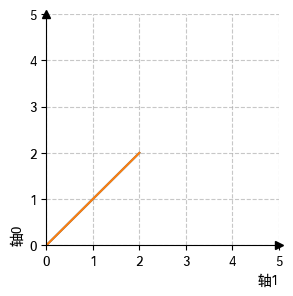

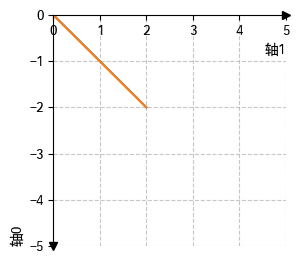

(None, None)

In [21]:
draw_down_top(([0,0], [1,1], [2,2])), draw_top_down(([0,0], [-1,-1], [-2,-2]))

沿着行和列对矩阵求和，等价于对矩阵的所有元素进行求和。


In [22]:
A.sum(axis=[0, 1])  # 结果和A.sum()相同

tensor(190.)

[**一个与求和相关的量是*平均值*（mean或average）**]。
我们通过将总和除以元素总数来计算平均值。
在代码中，我们可以调用函数来计算任意形状张量的平均值。


In [23]:
A.mean(), A.sum() / A.numel()

(tensor(9.5000), tensor(9.5000))

同样，计算平均值的函数也可以沿指定轴降低张量的维度。


In [24]:
A.mean(axis=0), A.sum(axis=0) / A.shape[0]

(tensor([ 8.,  9., 10., 11.]), tensor([ 8.,  9., 10., 11.]))

### 非降维求和

:label:`subseq_lin-alg-non-reduction`

但是，有时在调用函数来[**计算总和或均值时保持轴数不变**]会很有用。


In [25]:
A

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.],
        [12., 13., 14., 15.],
        [16., 17., 18., 19.]])

In [26]:
A.sum(axis=0)

tensor([40., 45., 50., 55.])

In [27]:
A.sum(axis=1)

tensor([ 6., 22., 38., 54., 70.])

In [28]:
(A.sum(axis=1)).T

/var/folders/w0/y_fylk8d1g5474hmb49dt1jr0000gn/T/ipykernel_4830/3682140420.py:1: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matricesor `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at  /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:2985.)
  (A.sum(axis=1)).T


tensor([ 6., 22., 38., 54., 70.])

In [29]:
sum_A = A.sum(axis=1, keepdims=True)
sum_A

tensor([[ 6.],
        [22.],
        [38.],
        [54.],
        [70.]])

例如，由于`sum_A`在对每行进行求和后仍保持两个轴，我们可以(**通过广播将`A`除以`sum_A`**)。


In [30]:
A / sum_A

tensor([[0.0000, 0.1667, 0.3333, 0.5000],
        [0.1818, 0.2273, 0.2727, 0.3182],
        [0.2105, 0.2368, 0.2632, 0.2895],
        [0.2222, 0.2407, 0.2593, 0.2778],
        [0.2286, 0.2429, 0.2571, 0.2714]])

如果我们想沿[**某个轴计算`A`元素的累积总和**]，
比如`axis=0`（按行计算），可以调用`cumsum`函数。
此函数不会沿任何轴降低输入张量的维度。


In [31]:
A

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.],
        [12., 13., 14., 15.],
        [16., 17., 18., 19.]])

In [32]:
A.cumsum(axis=0)

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  6.,  8., 10.],
        [12., 15., 18., 21.],
        [24., 28., 32., 36.],
        [40., 45., 50., 55.]])

## 点积（Dot Product）

我们已经学习了按元素操作、求和及平均值。
另一个最基本的操作之一是点积。
给定两个向量$\mathbf{x},\mathbf{y}\in\mathbb{R}^d$，
它们的*点积*（dot product）$\mathbf{x}^\top\mathbf{y}$
（或$\langle\mathbf{x},\mathbf{y}\rangle$）
是相同位置的按元素乘积的和：$\mathbf{x}^\top \mathbf{y} = \sum_{i=1}^{d} x_i y_i$。

[~~点积是相同位置的按元素乘积的和~~]


In [33]:
y = torch.ones(4, dtype = torch.float32)
x, y, torch.dot(x, y)

(tensor([0., 1., 2., 3.]), tensor([1., 1., 1., 1.]), tensor(6.))

注意，(**我们可以通过执行按元素乘法，然后进行求和来表示两个向量的点积**)：


In [34]:
torch.sum(x * y)

tensor(6.)

点积在很多场合都很有用。
例如，给定一组由向量$\mathbf{x} \in \mathbb{R}^d$表示的值，
和一组由$\mathbf{w} \in \mathbb{R}^d$表示的权重。
$\mathbf{x}$中的值根据权重$\mathbf{w}$的加权和，
可以表示为点积$\mathbf{x}^\top \mathbf{w}$。
当权重为非负数且和为1（即$\left(\sum_{i=1}^{d}{w_i}=1\right)$）时，
点积表示*加权平均*（weighted average）。
将两个向量规范化得到单位长度后，点积表示它们夹角的余弦。
本节后面的内容将正式介绍*长度*（length）的概念。

## 矩阵-向量积

现在我们知道如何计算点积，可以开始理解*矩阵-向量积*（matrix-vector product）。
回顾分别在 :eqref:`eq_matrix_def`和 :eqref:`eq_vec_def`中定义的矩阵$\mathbf{A} \in \mathbb{R}^{m \times n}$和向量$\mathbf{x} \in \mathbb{R}^n$。
让我们将矩阵$\mathbf{A}$用它的行向量表示：

$$\mathbf{A}=
\begin{bmatrix}
\mathbf{a}^\top_{1} \\
\mathbf{a}^\top_{2} \\
\vdots \\
\mathbf{a}^\top_m \\
\end{bmatrix},$$

其中每个$\mathbf{a}^\top_{i} \in \mathbb{R}^n$都是行向量，表示矩阵的第$i$行。
[**矩阵向量积$\mathbf{A}\mathbf{x}$是一个长度为$m$的列向量，
其第$i$个元素是点积$\mathbf{a}^\top_i \mathbf{x}$**]：

$$
\mathbf{A}\mathbf{x}
= \begin{bmatrix}
\mathbf{a}^\top_{1} \\
\mathbf{a}^\top_{2} \\
\vdots \\
\mathbf{a}^\top_m \\
\end{bmatrix}\mathbf{x}
= \begin{bmatrix}
 \mathbf{a}^\top_{1} \mathbf{x}  \\
 \mathbf{a}^\top_{2} \mathbf{x} \\
\vdots\\
 \mathbf{a}^\top_{m} \mathbf{x}\\
\end{bmatrix}.
$$

我们可以把一个矩阵$\mathbf{A} \in \mathbb{R}^{m \times n}$乘法看作一个从$\mathbb{R}^{n}$到$\mathbb{R}^{m}$向量的转换。
这些转换是非常有用的，例如可以用方阵的乘法来表示旋转。
后续章节将讲到，我们也可以使用矩阵-向量积来描述在给定前一层的值时，
求解神经网络每一层所需的复杂计算。


在代码中使用张量表示矩阵-向量积，我们使用`mv`函数。
当我们为矩阵`A`和向量`x`调用`torch.mv(A, x)`时，会执行矩阵-向量积。
注意，`A`的列维数（沿轴1的长度）必须与`x`的维数（其长度）相同。


In [35]:
A, x

(tensor([[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.],
         [12., 13., 14., 15.],
         [16., 17., 18., 19.]]),
 tensor([0., 1., 2., 3.]))

In [36]:
A.shape, x.shape, torch.mv(A, x)

(torch.Size([5, 4]), torch.Size([4]), tensor([ 14.,  38.,  62.,  86., 110.]))

In [37]:
torch.sum(A * x, dim=1)

tensor([ 14.,  38.,  62.,  86., 110.])

In [38]:
AA = torch.arange(6, dtype=torch.float32).reshape(2, 3)
# x = torch.ones(3, dtype=torch.float32)
# x = torch.arange(3, dtype=torch.float32)
xx = torch.tensor([3, 9, 7], dtype=torch.float32)
AA, xx, torch.mv(AA, xx) # 按 列1 转置 依次相乖并求和得到新的 轴0 的值，即按 轴1 进行降维，再求和， 0x0+1x1+2x2=5, 3x0+4x1+5x2=14

(tensor([[0., 1., 2.],
         [3., 4., 5.]]),
 tensor([3., 9., 7.]),
 tensor([23., 80.]))

In [39]:
torch.sum(AA * xx, dim=1)

tensor([23., 80.])

In [40]:
torch.sum(AA * xx, dim=1) == torch.mv(AA, xx)

tensor([True, True])

## 矩阵-矩阵乘法

在掌握点积和矩阵-向量积的知识后，
那么**矩阵-矩阵乘法**（matrix-matrix multiplication）应该很简单。

假设有两个矩阵$\mathbf{A} \in \mathbb{R}^{n \times k}$和$\mathbf{B} \in \mathbb{R}^{k \times m}$：

$$\mathbf{A}=\begin{bmatrix}
 a_{11} & a_{12} & \cdots & a_{1k} \\
 a_{21} & a_{22} & \cdots & a_{2k} \\
\vdots & \vdots & \ddots & \vdots \\
 a_{n1} & a_{n2} & \cdots & a_{nk} \\
\end{bmatrix},\quad
\mathbf{B}=\begin{bmatrix}
 b_{11} & b_{12} & \cdots & b_{1m} \\
 b_{21} & b_{22} & \cdots & b_{2m} \\
\vdots & \vdots & \ddots & \vdots \\
 b_{k1} & b_{k2} & \cdots & b_{km} \\
\end{bmatrix}.$$

用行向量$\mathbf{a}^\top_{i} \in \mathbb{R}^k$表示矩阵$\mathbf{A}$的第$i$行，并让列向量$\mathbf{b}_{j} \in \mathbb{R}^k$作为矩阵$\mathbf{B}$的第$j$列。要生成矩阵积$\mathbf{C} = \mathbf{A}\mathbf{B}$，最简单的方法是考虑$\mathbf{A}$的行向量和$\mathbf{B}$的列向量:

$$\mathbf{A}=
\begin{bmatrix}
\mathbf{a}^\top_{1} \\
\mathbf{a}^\top_{2} \\
\vdots \\
\mathbf{a}^\top_n \\
\end{bmatrix},
\quad \mathbf{B}=\begin{bmatrix}
 \mathbf{b}_{1} & \mathbf{b}_{2} & \cdots & \mathbf{b}_{m} \\
\end{bmatrix}.
$$
当我们简单地将每个元素$c_{ij}$计算为点积$\mathbf{a}^\top_i \mathbf{b}_j$:

$$\mathbf{C} = \mathbf{AB} = \begin{bmatrix}
\mathbf{a}^\top_{1} \\
\mathbf{a}^\top_{2} \\
\vdots \\
\mathbf{a}^\top_n \\
\end{bmatrix}
\begin{bmatrix}
 \mathbf{b}_{1} & \mathbf{b}_{2} & \cdots & \mathbf{b}_{m} \\
\end{bmatrix}
= \begin{bmatrix}
\mathbf{a}^\top_{1} \mathbf{b}_1 & \mathbf{a}^\top_{1}\mathbf{b}_2& \cdots & \mathbf{a}^\top_{1} \mathbf{b}_m \\
 \mathbf{a}^\top_{2}\mathbf{b}_1 & \mathbf{a}^\top_{2} \mathbf{b}_2 & \cdots & \mathbf{a}^\top_{2} \mathbf{b}_m \\
 \vdots & \vdots & \ddots &\vdots\\
\mathbf{a}^\top_{n} \mathbf{b}_1 & \mathbf{a}^\top_{n}\mathbf{b}_2& \cdots& \mathbf{a}^\top_{n} \mathbf{b}_m
\end{bmatrix}.
$$

[**我们可以将矩阵-矩阵乘法$\mathbf{AB}$看作简单地执行$m$次矩阵-向量积，并将结果拼接在一起，形成一个$n \times m$矩阵**]。
在下面的代码中，我们在`A`和`B`上执行矩阵乘法。
这里的`A`是一个5行4列的矩阵，`B`是一个4行3列的矩阵。
两者相乘后，我们得到了一个5行3列的矩阵。


In [41]:
A

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.],
        [12., 13., 14., 15.],
        [16., 17., 18., 19.]])

In [42]:
B = torch.ones(4, 3)
torch.mm(A, B)

tensor([[ 6.,  6.,  6.],
        [22., 22., 22.],
        [38., 38., 38.],
        [54., 54., 54.],
        [70., 70., 70.]])

In [43]:
B

tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])

矩阵-矩阵乘法可以简单地称为**矩阵乘法**，不应与"Hadamard积"混淆。

## 范数
:label:`subsec_lin-algebra-norms`

线性代数中最有用的一些运算符是*范数*（norm）。
非正式地说，向量的*范数*是表示一个向量有多大。
这里考虑的*大小*（size）概念不涉及维度，而是分量的大小。

在线性代数中，向量范数是将向量映射到标量的函数$f$。
给定任意向量$\mathbf{x}$，向量范数要满足一些属性。
第一个性质是：如果我们按常数因子$\alpha$缩放向量的所有元素，
其范数也会按相同常数因子的*绝对值*缩放：

$$f(\alpha \mathbf{x}) = |\alpha| f(\mathbf{x}).$$

第二个性质是熟悉的三角不等式:

$$f(\mathbf{x} + \mathbf{y}) \leq f(\mathbf{x}) + f(\mathbf{y}).$$

第三个性质简单地说范数必须是非负的:

$$f(\mathbf{x}) \geq 0.$$

这是有道理的。因为在大多数情况下，任何东西的最小的*大小*是0。
最后一个性质要求范数最小为0，当且仅当向量全由0组成。

$$\forall i, [\mathbf{x}]_i = 0 \Leftrightarrow f(\mathbf{x})=0.$$

范数听起来很像距离的度量。
欧几里得距离和毕达哥拉斯定理中的非负性概念和三角不等式可能会给出一些启发。
事实上，欧几里得距离是一个$L_2$范数：
假设$n$维向量$\mathbf{x}$中的元素是$x_1,\ldots,x_n$，其[**$L_2$*范数*是向量元素平方和的平方根：**]

(**$$\|\mathbf{x}\|_2 = \sqrt{\sum_{i=1}^n x_i^2},$$**)

其中，在$L_2$范数中常常省略下标$2$，也就是说$\|\mathbf{x}\|$等同于$\|\mathbf{x}\|_2$。
在代码中，我们可以按如下方式计算向量的$L_2$范数。


In [44]:
u = torch.tensor([3.0, -4.0])
torch.norm(u)

tensor(5.)

深度学习中更经常地使用$L_2$范数的平方，也会经常遇到[**$L_1$范数，它表示为向量元素的绝对值之和：**]

(**$$\|\mathbf{x}\|_1 = \sum_{i=1}^n \left|x_i \right|.$$**)

与$L_2$范数相比，$L_1$范数受异常值的影响较小。
为了计算$L_1$范数，我们将绝对值函数和按元素求和组合起来。


In [45]:
torch.abs(u).sum()

tensor(7.)

$L_2$范数和$L_1$范数都是更一般的$L_p$范数的特例：

$$\|\mathbf{x}\|_p = \left(\sum_{i=1}^n \left|x_i \right|^p \right)^{1/p}.$$

类似于向量的$L_2$范数，[**矩阵**]$\mathbf{X} \in \mathbb{R}^{m \times n}$(**的*Frobenius范数*（Frobenius norm）是矩阵元素平方和的平方根：**)

(**$$\|\mathbf{X}\|_F = \sqrt{\sum_{i=1}^m \sum_{j=1}^n x_{ij}^2}.$$**)

Frobenius范数满足向量范数的所有性质，它就像是矩阵形向量的$L_2$范数。
调用以下函数将计算矩阵的Frobenius范数。


In [46]:
torch.norm(torch.ones((4, 9)))

tensor(6.)

In [47]:
torch.ones((4, 9))

tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1.]])

In [48]:
torch.sqrt(torch.sum(torch.ones((4, 9)) ** 2))

tensor(6.)

### 范数和目标

:label:`subsec_norms_and_objectives`

在深度学习中，我们经常试图解决优化问题：
*最大化*分配给观测数据的概率;
*最小化*预测和真实观测之间的距离。
用向量表示物品（如单词、产品或新闻文章），以便最小化相似项目之间的距离，最大化不同项目之间的距离。
目标，或许是深度学习算法最重要的组成部分（除了数据），通常被表达为范数。

## 关于线性代数的更多信息

仅用一节，我们就教会了阅读本书所需的、用以理解现代深度学习的线性代数。
线性代数还有很多，其中很多数学对于机器学习非常有用。
例如，矩阵可以分解为因子，这些分解可以显示真实世界数据集中的低维结构。
机器学习的整个子领域都侧重于使用矩阵分解及其向高阶张量的泛化，来发现数据集中的结构并解决预测问题。
当开始动手尝试并在真实数据集上应用了有效的机器学习模型，你会更倾向于学习更多数学。
因此，这一节到此结束，本书将在后面介绍更多数学知识。

如果渴望了解有关线性代数的更多信息，可以参考[线性代数运算的在线附录](https://d2l.ai/chapter_appendix-mathematics-for-deep-learning/geometry-linear-algebraic-ops.html)或其他优秀资源 :cite:`Strang.1993,Kolter.2008,Petersen.Pedersen.ea.2008`。

## 小结

* 标量、向量、矩阵和张量是线性代数中的基本数学对象。
* 向量泛化自标量，矩阵泛化自向量。
* 标量、向量、矩阵和张量分别具有零、一、二和任意数量的轴。
* 一个张量可以通过`sum`和`mean`沿指定的轴降低维度。
* 两个矩阵的按元素乘法被称为他们的Hadamard积。它与矩阵乘法不同。
* 在深度学习中，我们经常使用范数，如$L_1$范数、$L_2$范数和Frobenius范数。
* 我们可以对标量、向量、矩阵和张量执行各种操作。

## 练习

1. 证明一个矩阵$\mathbf{A}$的转置的转置是$\mathbf{A}$，即$(\mathbf{A}^\top)^\top = \mathbf{A}$。
1. 给出两个矩阵$\mathbf{A}$和$\mathbf{B}$，证明“它们转置的和”等于“它们和的转置”，即$\mathbf{A}^\top + \mathbf{B}^\top = (\mathbf{A} + \mathbf{B})^\top$。
1. 给定任意方阵$\mathbf{A}$，$\mathbf{A} + \mathbf{A}^\top$总是对称的吗?为什么?
1. 本节中定义了形状$(2,3,4)$的张量`X`。`len(X)`的输出结果是什么？
1. 对于任意形状的张量`X`,`len(X)`是否总是对应于`X`特定轴的长度?这个轴是什么?
1. 运行`A/A.sum(axis=1)`，看看会发生什么。请分析一下原因？
1. 考虑一个具有形状$(2,3,4)$的张量，在轴0、1、2上的求和输出是什么形状?
1. 为`linalg.norm`函数提供3个或更多轴的张量，并观察其输出。对于任意形状的张量这个函数计算得到什么?


[Discussions](https://discuss.d2l.ai/t/1751)


In [49]:
A.shape, A.sum(axis=0).shape, A.sum(axis=1).shape

(torch.Size([5, 4]), torch.Size([4]), torch.Size([5]))

In [50]:
A/A.sum(axis=0)

tensor([[0.0000, 0.0222, 0.0400, 0.0545],
        [0.1000, 0.1111, 0.1200, 0.1273],
        [0.2000, 0.2000, 0.2000, 0.2000],
        [0.3000, 0.2889, 0.2800, 0.2727],
        [0.4000, 0.3778, 0.3600, 0.3455]])

In [51]:
X, len(X), X.shape

(tensor([[[ 0,  1,  2,  3],
          [ 4,  5,  6,  7],
          [ 8,  9, 10, 11]],
 
         [[12, 13, 14, 15],
          [16, 17, 18, 19],
          [20, 21, 22, 23]]]),
 2,
 torch.Size([2, 3, 4]))

In [52]:
X.sum(dim=0), X.sum(dim=1), X.sum(dim=2)

(tensor([[12, 14, 16, 18],
         [20, 22, 24, 26],
         [28, 30, 32, 34]]),
 tensor([[12, 15, 18, 21],
         [48, 51, 54, 57]]),
 tensor([[ 6, 22, 38],
         [54, 70, 86]]))

In [53]:
from torch import linalg as LA
A = torch.arange(9, dtype=torch.float).reshape(3, 3)
A

tensor([[0., 1., 2.],
        [3., 4., 5.],
        [6., 7., 8.]])

In [54]:

LA.matrix_norm(A)

tensor(14.2829)

In [55]:
LA.matrix_norm(A, ord=-1)

tensor(9.)

In [56]:
B = A.expand(2, -1, -1)
B

tensor([[[0., 1., 2.],
         [3., 4., 5.],
         [6., 7., 8.]],

        [[0., 1., 2.],
         [3., 4., 5.],
         [6., 7., 8.]]])

In [57]:
LA.matrix_norm(B)

tensor([14.2829, 14.2829])

In [58]:
LA.matrix_norm(B, dim=(0, 2))

tensor([ 3.1623, 10.0000, 17.2627])